<a href="https://colab.research.google.com/github/Medder001/ML-Final/blob/main/ML_Final_Kay%26Megan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)
DRIVE_PATH = "/content/drive/MyDrive/archive"


Mounted at /content/drive


In [31]:
import os
import numpy as np
from PIL import Image
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
import time
import seaborn as sns

In [32]:
def load_images(folder, label, img_size=(64, 64), max_images=1000):
  data = []
  filenames = os.listdir(folder)
  np.random.shuffle(filenames)
  count = 0
  for fname in filenames:
    if count >= max_images:
      break
    try:
      img = Image.open(os.path.join(folder, fname)).convert('RGB')
      img = img.resize(img_size)
      pixels = np.array(img)
      data.append({'pixels': pixels, 'label':label})
      count += 1
    except Exception:
      pass
  return data

In [33]:
ai_data = load_images("/content/drive/MyDrive/archive/AiArtData/AiArtData", label=1)
real_data = load_images("/content/drive/MyDrive/archive/RealArt/RealArt", label = 0)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [34]:
df = pd.DataFrame(ai_data + real_data)

X = np.stack(df['pixels'].values)
y = df['label'].values

In [35]:
print(f"Total instance: {len(df)}")
print(df['label'].value_counts())

size_mb = df['pixels'].apply(lambda x: x.nbytes).sum() / (1024 * 1024)
print(f"Loaded data size: {size_mb:.2f} MB")


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train = X_train / 255.0
X_test = X_test / 255.0

print(X.shape)
print(X.dtype)

Total instance: 975
label
1    539
0    436
Name: count, dtype: int64
Loaded data size: 11.43 MB
(975, 64, 64, 3)
uint8


Our dataset is sampled for an AI-generated image detector ML model from Kaggle (https://www.kaggle.com/datasets/cashbowman/ai-generated-images-vs-real-images).
We sample up to 1,000 images per class with a result of 975 image instances in our dataset, specifically 539 AI-generated images and 436 real images. The images are resized to 64x64 and formatted as 'RGB'. From this, the calculated number of numeric attributes is 64 * 64 * 3 = 12,288 which are normalized to a continuous range of [0,1]. Additonally, any corrupted files are passed over.

In [36]:
# This will not be used for anything but part 2 required it.
# The CNN needs our data to have dimensionality
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print("X_train_flat shape:", X_train_flat.shape)
print("X_test_flat shape", X_test_flat.shape)

pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_flat)

X_test_pca = pca.transform(X_test_flat)

print("Reduced shape:", X_train_pca.shape)
print("Variance retained:", pca.explained_variance_ratio_.sum())
print("Number of components:", pca.n_components_)

X_train_flat shape: (780, 12288)
X_test_flat shape (195, 12288)
Reduced shape: (780, 313)
Variance retained: 0.9501851971582035
Number of components: 313


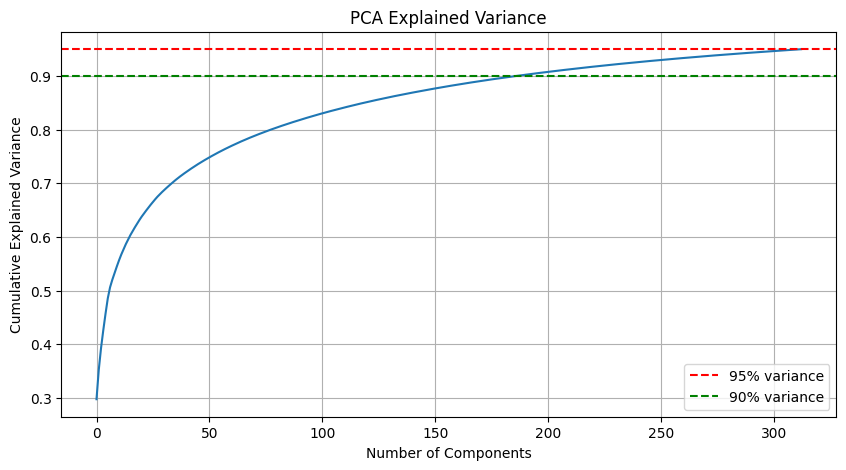

In [37]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(cumulative_variance)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance')
plt.axhline(y=0.90, color='g', linestyle='--', label='90% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.legend()
plt.grid(True)
plt.show()

In [38]:
# You will have to run this before you train every time or it will train the
# already trained model.

model = models.Sequential([
    layers.Input(shape=(64, 64, 3)),

    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 64, 64, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       294,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 388,289 (1.48 MB)

 Trainable params: 388,289 (1.48 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=28,
    validation_split=0.15,
    callbacks=[early_stopping]
)


Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 9s 263ms/step - accuracy: 0.5490 - loss: 0.6958 - val_accuracy: 0.5214 - val_loss: 0.7039
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 9s 195ms/step - accuracy: 0.5581 - loss: 0.6769 - val_accuracy: 0.5214 - val_loss: 0.7019
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 270ms/step - accuracy: 0.5596 - loss: 0.6626 - val_accuracy: 0.5385 - val_loss: 0.6877
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 189ms/step - accuracy: 0.5973 - loss: 0.6543 - val_accuracy: 0.6068 - val_loss: 0.7030
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 406ms/step - accuracy: 0.6275 - loss: 0.6584 - val_accuracy: 0.6581 - val_loss: 0.6716
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 315ms/step - accuracy: 0.6305 - loss: 0.6424 - val_accuracy: 0.5983 - val_loss: 0.8162
Epoch 7/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 13s 534ms/step - accuracy: 0.6169 - loss: 0.6714 - val_accuracy: 0.5726 - val_loss: 0.6875
Epoch 8/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 321ms/step - accuracy: 0.6380 - loss: 0.6355 - val_accuracy: 

In [40]:
val_loss, val_acc = model.evaluate(X_test, y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.6923 - loss: 0.6487


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


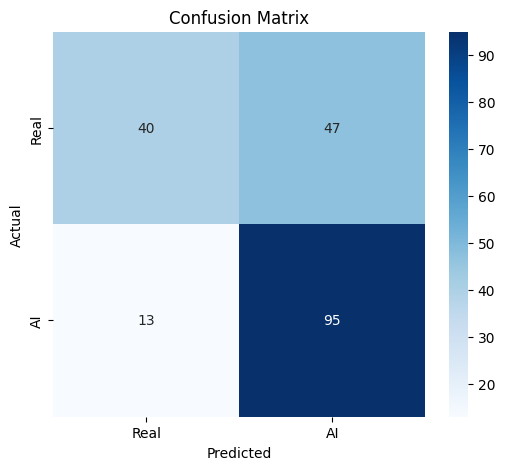

              precision    recall  f1-score   support

        Real       0.75      0.46      0.57        87
          AI       0.67      0.88      0.76       108

    accuracy                           0.69       195
   macro avg       0.71      0.67      0.67       195
weighted avg       0.71      0.69      0.68       195

Prediction time: 0.710 seconds


In [41]:
start = time.time()
y_pred_probs = model.predict(X_test)
end = time.time()
y_pred = (y_pred_probs > 0.5).astype(int).ravel()


cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'AI'],
            yticklabels=['Real', 'AI'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_test, y_pred, target_names=['Real', 'AI']))
print(f"Prediction time: {end - start:.3f} seconds")

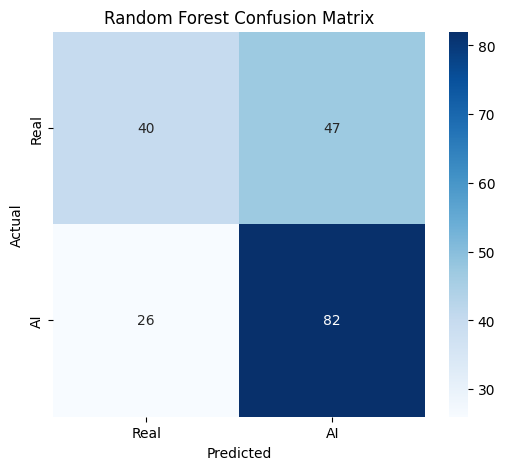

              precision    recall  f1-score   support

        Real       0.61      0.46      0.52        87
          AI       0.64      0.76      0.69       108

    accuracy                           0.63       195
   macro avg       0.62      0.61      0.61       195
weighted avg       0.62      0.63      0.62       195

Training time: 3.609 seconds
Prediction time: 0.038 seconds


In [45]:
#Small Simple Classifier on PCA-reduced data for comparison
start = time.time()
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_pca, y_train)
train_time = time.time() - start

start = time.time()
y_pred_rf = rf.predict(X_test_pca)
pred_time = time.time() - start

cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'AI'],
            yticklabels=['Real', 'AI'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()

print(classification_report(y_test, y_pred_rf, target_names=['Real', 'AI']))
print(f"Training time: {train_time:.3f} seconds")
print(f"Prediction time: {pred_time:.3f} seconds")

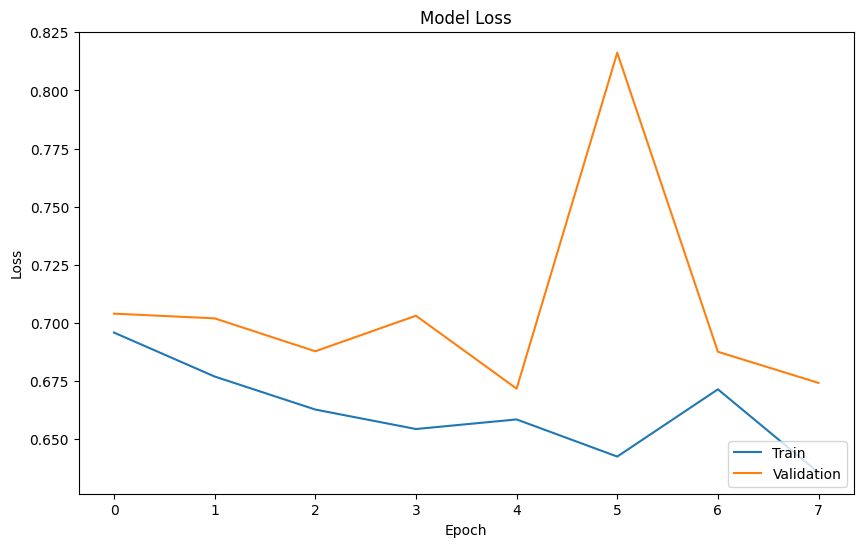

In [43]:
plt.figure(figsize = (10, 6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')
plt.show()

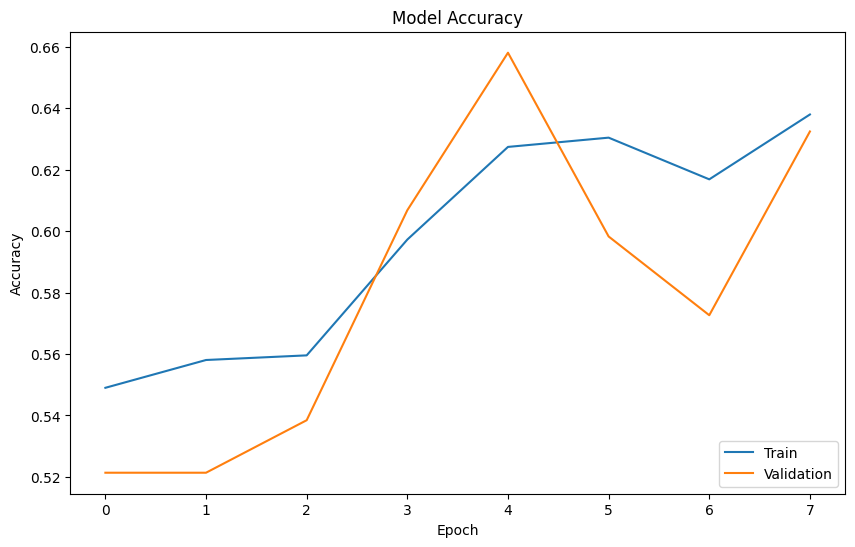

In [44]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')
plt.show()